# Sistema Multi-Agente de Detecção de Spam - Versão Corrigida

Esta versão implementa um sistema avançado de detecção de spam usando múltiplos agentes especializados com:

## 🎯 Principais Correções:
- **OpenAI configurado corretamente** com fallback robusto
- **LLM Classifier otimizado** para melhor performance
- **Métricas e pesos balanceados** para maior precisão
- **Sistema de agregação inteligente** com thresholds ajustados
- **Integração adequada com datasets** reais

## 🤖 Agentes Integrados:
1. **SanitizationAgent** - Limpeza e normalização de texto
2. **PromptInjectionAgent** - Detecção de tentativas de prompt injection
3. **LLMClassifier** - Classificação contextual usando OpenAI GPT
4. **HashAnalyzer** - Verificação de hashes maliciosos conhecidos
5. **MaliciousContentAgent** - Detecção de phishing e URLs maliciosas
6. **ResultAggregator** - Agregação ponderada dos resultados finais

In [ ]:
# Instalação de dependências
%pip install langgraph
%pip install langchain_openai
%pip install langchain_core
%pip install python-dotenv
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install tqdm
%pip install numpy
%pip install scikit-learn
%pip install guardrails-ai

Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


Note: you may need to restart the kernel to use updated packages.


...

Could not find platform independent libraries <prefix>


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [5]:
# Imports principais
import os
import json
import pandas as pd
import numpy as np
from typing import TypedDict, List, Dict, Any, Optional
from datetime import datetime
import time
import re
import hashlib
import unicodedata
from urllib.parse import urlparse
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# LangGraph e LangChain
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage

# Configuração de ambiente
from dotenv import load_dotenv
load_dotenv()

# Configurar visualização
plt.style.use('default')
sns.set_palette("husl")

print("✅ Todas as dependências importadas com sucesso!")

✅ Todas as dependências importadas com sucesso!


In [6]:
# Configuração da OpenAI API - VERSÃO CORRIGIDA
import os
from dotenv import load_dotenv

# Carrega variáveis do arquivo .env se existir
load_dotenv()

# Tenta obter a chave do ambiente primeiro
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# Se não encontrou no ambiente, permite configuração manual
# SUBSTITUA PELA SUA CHAVE REAL DA OPENAI:
if not OPENAI_API_KEY:
    OPENAI_API_KEY = "sua_chave_openai_aqui"  # Cole sua chave aqui

# Configura a chave se válida
if OPENAI_API_KEY and len(OPENAI_API_KEY) > 20 and OPENAI_API_KEY.startswith("sk-"):
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
    print("✅ Chave da OpenAI configurada corretamente")
    USE_OPENAI = True
    
    # Inicializar modelo LLM
    try:
        model = ChatOpenAI(model="gpt-5", temperature=0.1)
        print("✅ Modelo OpenAI GPT-5 inicializado")
    except Exception as e:
        print(f"⚠️ Erro ao inicializar OpenAI: {e}")
        USE_OPENAI = False
        model = None
else:
    print("⚠️ ATENÇÃO: Configure uma chave válida da OpenAI para usar GPT")
    print("O sistema usará classificação baseada em padrões como fallback.")
    print("\n📝 Para configurar:")
    print("1. Obtenha uma API key em https://platform.openai.com/api-keys")
    print("2. Substitua 'sua_chave_openai_aqui' pela sua chave real")
    print("3. Ou configure a variável de ambiente OPENAI_API_KEY")
    USE_OPENAI = False
    model = None

print(f"\n🔧 Configuração atual: OpenAI {'✅ ATIVO' if USE_OPENAI else '❌ INATIVO (usando fallback)'}")

✅ Chave da OpenAI configurada corretamente
✅ Modelo OpenAI GPT-5 inicializado

🔧 Configuração atual: OpenAI ✅ ATIVO


In [7]:
# SanitizationAgent - Limpeza e normalização de texto
class SanitizationAgent:
    """Agente responsável por limpeza e normalização de texto"""

    def __init__(self):
        self.unicode_patterns = [
            r'[\u202e\u202d\u202c]',  # Direção de texto
            r'[\u0000-\u0008\u000B\u000C\u000E-\u001F\u007F-\u009F]',  # Caracteres de controle
            r'[\u2000-\u200F\u2028-\u202F\u205F-\u206F]',  # Separadores e formatação
            r'[\ufeff]',  # BOM (Byte Order Mark)
        ]
    
    def normalize_unicode(self, text: str) -> str:
        try:
            return unicodedata.normalize('NFKC', text)
        except Exception:
            return text

    def remove_control_characters(self, text: str) -> str:
        for pattern in self.unicode_patterns:
            text = re.sub(pattern, '', text)
        return text

    def clean_whitespace(self, text: str) -> str:
        text = re.sub(r'[\u2000-\u200F\u2028-\u202F\u205F-\u206F]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def remove_html_tags(self, text: str) -> str:
        text = re.sub(r'<[^>]+>', '', text)
        html_entities = {
            '&amp;': '&', '&lt;': '<', '&gt;': '>', '&quot;': '"',
            '&#39;': "'", '&nbsp;': ' '
        }
        for entity, char in html_entities.items():
            text = text.replace(entity, char)
        return text

    def process(self, email_text: str) -> Dict[str, Any]:
        if not isinstance(email_text, str):
            email_text = str(email_text)

        original_length = len(email_text)
        cleaned = email_text

        # Pipeline de limpeza
        cleaned = self.normalize_unicode(cleaned)
        cleaned = self.remove_control_characters(cleaned)
        cleaned = self.remove_html_tags(cleaned)
        cleaned = self.clean_whitespace(cleaned)

        cleaned_length = len(cleaned)
        chars_removed = original_length - cleaned_length
        cleanup_ratio = chars_removed / original_length if original_length > 0 else 0

        return {
            'cleaned_text': cleaned,
            'original_length': original_length,
            'cleaned_length': cleaned_length,
            'chars_removed': chars_removed,
            'cleanup_ratio': cleanup_ratio,
            'agent': 'sanitization'
        }

print("✅ SanitizationAgent implementado")

✅ SanitizationAgent implementado


In [8]:
# PromptInjectionAgent - Detecção de tentativas de prompt injection
class PromptInjectionAgent:
    """Detecta tentativas de prompt injection"""

    def __init__(self):
        self.injection_patterns = [
            r'(?i)(ignore|forget|disregard).{0,20}(previous|above|earlier|prior).{0,20}(instruction|prompt|rule)',
            r'(?i)(act|behave|pretend|roleplay).{0,20}as.{0,20}(dan|evil|jailbreak|unrestricted)',
            r'(?i)(from\s+now\s+on|starting\s+now).{0,30}(you\s+are|act\s+as|behave\s+as)',
            r'(?i)(bypass|override|disable|turn\s+off).{0,20}(safety|filter|restriction|guardrail)',
            r'(?i)(developer\s+mode|god\s+mode|admin\s+mode|root\s+access)',
            r'(?i)(tell\s+me\s+how\s+to).{0,50}(hack|exploit|manipulate|deceive)',
            r'(?i)(you\s+must|you\s+have\s+to|you\s+are\s+required).{0,30}(answer|respond|tell)',
            r'(?i)(ignore\s+your|forget\s+your).{0,20}(training|programming|guidelines)',
            r'(?i)repeat\s+after\s+me\s*:',
            r'(?i)(system\s+prompt|system\s+message).{0,20}(override|change|modify)',
        ]

        self.suspicious_keywords = [
            'jailbreak', 'dan', 'unrestricted', 'unfiltered', 'uncensored',
            'bypass', 'override', 'disable', 'ignore instructions',
            'developer mode', 'admin mode', 'god mode', 'root access',
            'forget previous', 'ignore previous', 'disregard previous',
            'act as if', 'pretend to be', 'roleplay as'
        ]
        
        # Load datasets from archive directory
        self.jailbreak_prompts = set()
        self.forbidden_questions = set()
        self.load_injection_datasets()

    def load_injection_datasets(self):
        """Load prompt injection datasets from archive directory"""
        try:
            # Load jailbreak prompts
            if os.path.exists('archive/jailbreak_prompts.csv'):
                jailbreak_df = pd.read_csv('archive/jailbreak_prompts.csv')
                if 'prompt' in jailbreak_df.columns:
                    self.jailbreak_prompts.update(jailbreak_df['prompt'].dropna().astype(str).tolist())
                elif 'text' in jailbreak_df.columns:
                    self.jailbreak_prompts.update(jailbreak_df['text'].dropna().astype(str).tolist())
                print(f"✅ Carregados {len(self.jailbreak_prompts)} jailbreak prompts")

            # Load forbidden questions
            if os.path.exists('archive/forbidden_question_set_df.csv'):
                forbidden_df = pd.read_csv('archive/forbidden_question_set_df.csv')
                if 'question' in forbidden_df.columns:
                    self.forbidden_questions.update(forbidden_df['question'].dropna().astype(str).tolist())
                elif 'text' in forbidden_df.columns:
                    self.forbidden_questions.update(forbidden_df['text'].dropna().astype(str).tolist())
                print(f"✅ Carregadas {len(self.forbidden_questions)} forbidden questions")
                
            # Load additional malicious datasets
            if os.path.exists('archive/malicous_deepset.csv'):
                malicious_df = pd.read_csv('archive/malicous_deepset.csv')
                if 'text' in malicious_df.columns:
                    self.jailbreak_prompts.update(malicious_df['text'].dropna().astype(str).tolist())
                elif 'prompt' in malicious_df.columns:
                    self.jailbreak_prompts.update(malicious_df['prompt'].dropna().astype(str).tolist())
                print(f"✅ Carregados prompts maliciosos adicionais")

        except Exception as e:
            print(f"⚠️ Erro ao carregar datasets de injection: {e}")
            print("Usando apenas padrões predefinidos")

    def detect_pattern_injection(self, text: str) -> Dict[str, Any]:
        text_lower = text.lower()
        detected_patterns = []
        detected_methods = []

        # Pattern matching
        for pattern in self.injection_patterns:
            if re.search(pattern, text, re.IGNORECASE):
                detected_patterns.append(pattern)
                detected_methods.append("pattern_match")

        keyword_count = 0
        detected_keywords = []
        for keyword in self.suspicious_keywords:
            if keyword in text_lower:
                keyword_count += 1
                detected_keywords.append(keyword)

        # Check against jailbreak prompts dataset
        jailbreak_matches = 0
        for jailbreak in list(self.jailbreak_prompts)[:1000]:  # Limit for performance
            try:
                if len(jailbreak) > 10:
                    jailbreak_lower = str(jailbreak).lower()
                    if jailbreak_lower in text_lower or text_lower in jailbreak_lower:
                        jailbreak_matches += 1
                        detected_methods.append("jailbreak_dataset")
                        if jailbreak_matches >= 3:
                            break
            except:
                continue

        pattern_score = len(detected_patterns) * 0.3
        keyword_score = keyword_count * 0.15
        jailbreak_score = jailbreak_matches * 0.4

        return {
            'pattern_score': min(pattern_score, 1.0),
            'keyword_score': min(keyword_score, 1.0),
            'jailbreak_score': min(jailbreak_score, 1.0),
            'detected_patterns': detected_patterns,
            'detected_keywords': detected_keywords,
            'detected_methods': detected_methods,
            'total_patterns': len(detected_patterns),
            'total_keywords': keyword_count,
            'jailbreak_matches': jailbreak_matches,
        }

    def process(self, email_data: Dict[str, Any]) -> Dict[str, Any]:
        text = email_data.get('cleaned_text', '')
        pattern_result = self.detect_pattern_injection(text)

        # Combined scoring
        final_score = (
            pattern_result['pattern_score'] * 0.4 +
            pattern_result['keyword_score'] * 0.3 +
            pattern_result['jailbreak_score'] * 0.3
        )

        is_injection = final_score > 0.6  # Higher threshold for better precision

        return {
            'prompt_injection_score': min(final_score, 1.0),
            'is_prompt_injection': is_injection,
            'pattern_detection': pattern_result,
            'dataset_size': {
                'jailbreak_prompts': len(self.jailbreak_prompts),
                'forbidden_questions': len(self.forbidden_questions),
                'total_patterns': len(self.injection_patterns)
            },
            'agent': 'prompt_injection'
        }

print("✅ PromptInjectionAgent implementado")

✅ PromptInjectionAgent implementado


In [9]:
# LLMClassifier - Versão Corrigida e Otimizada
class LLMClassifier:
    """Classificador usando LLM com fallback robusto"""

    def __init__(self, use_openai=None):
        # Se use_openai não foi especificado, usa a configuração global
        if use_openai is None:
            self.use_openai = USE_OPENAI
        else:
            self.use_openai = use_openai and USE_OPENAI
        
        # Padrões de fallback melhorados
        self.spam_indicators = {
            'urgency': ['urgent', 'immediate', 'act now', 'expires', 'limited time', 'hurry', 'rush', 'asap'],
            'money': ['prize', 'winner', '$', 'million', 'free', 'cash', 'earn', 'income', 'money', 'profit'],
            'action': ['click', 'verify', 'confirm', 'update', 'download', 'install', 'login', 'visit'],
            'threat': ['suspended', 'blocked', 'disabled', 'terminated', 'account locked', 'expired'],
            'deception': ['congratulations', 'selected', 'chosen', 'winner', 'lottery', 'inheritance', 'reward']
        }

    def classify_with_openai(self, text: str) -> tuple:
        """Classifica usando OpenAI GPT - versão otimizada"""
        try:
            # Prompt otimizado e mais claro
            prompt = f"""Analyze this email content for spam/phishing characteristics.

Email: {text[:1000]}  # Limitar tamanho para evitar tokens excessivos

Consider:
1. Urgency tactics
2. Money/prize offers
3. Suspicious links or requests
4. Grammar issues
5. Social engineering

Respond with ONLY:
- "SPAM" if suspicious/malicious
- "HAM" if legitimate

Answer:"""
            
            messages = [HumanMessage(content=prompt)]
            response = model.invoke(messages)
            response_text = response.content.lower().strip()
            
            # Análise mais robusta da resposta
            if "spam" in response_text and "ham" not in response_text:
                return 0.85, ['spam']  # High confidence for spam
            elif "ham" in response_text and "spam" not in response_text:
                return 0.15, ['ham']   # Low risk for legitimate emails
            else:
                # Resposta ambígua, usar fallback
                return self.classify_with_patterns(text)
                
        except Exception as e:
            print(f"LLM error: {e}")
            return self.classify_with_patterns(text)

    def classify_with_patterns(self, text: str) -> tuple:
        """Classificação usando pattern matching otimizada"""
        text_lower = text.lower()
        score = 0
        detected_categories = []
        category_scores = {}

        for category, keywords in self.spam_indicators.items():
            category_score = 0
            matches = 0
            for keyword in keywords:
                if keyword in text_lower:
                    matches += 1
                    category_score += 0.15  # Reduzido para menor sensibilidade
            
            if matches > 0:
                detected_categories.append(category)
                category_scores[category] = category_score
                score += category_score

        # Penalidade por múltiplas categorias (indicativo de spam)
        if len(detected_categories) >= 3:
            score += 0.2

        final_score = min(score, 0.95)  # Cap no score
        return final_score, detected_categories

    def process(self, email_data: Dict[str, Any]) -> Dict[str, Any]:
        text = email_data.get('cleaned_text', '')
        
        if self.use_openai and model is not None:
            confidence, categories = self.classify_with_openai(text)
            method = "openai_gpt"
        else:
            confidence, categories = self.classify_with_patterns(text)
            method = "pattern_matching"

        classification = 'spam' if confidence > 0.5 else 'ham'

        return {
            'llm_classification': classification,
            'confidence': confidence,
            'risk_score': confidence,
            'detected_categories': categories,
            'method': method,
            'use_openai': self.use_openai,
            'agent': 'llm_classifier'
        }

print("✅ LLMClassifier otimizado implementado")

✅ LLMClassifier otimizado implementado


In [10]:
# HashAnalyzer - Verificação de hashes maliciosos
class HashAnalyzer:
    """Agente de verificação de hashes maliciosos"""

    def __init__(self):
        self.known_malicious_hashes = set()
        self.load_malicious_hashes()

    def load_malicious_hashes(self):
        """Load malicious hashes from dataset files"""
        hash_files = [
            'malicious-hash/full-hash-md5-aa.txt',
            'malicious-hash/full-hash-sha1-aa.txt',
            'malicious-hash/full-hash-sha256-aa.txt'
        ]

        total_loaded = 0
        for file_path in hash_files:
            try:
                if os.path.exists(file_path):
                    with open(file_path, 'r', encoding='utf-8') as f:
                        file_hashes = 0
                        for line in f:
                            hash_value = line.strip()
                            if hash_value and len(hash_value) >= 32:
                                self.known_malicious_hashes.add(hash_value.lower())
                                file_hashes += 1
                    print(f"✅ Carregados {file_hashes} hashes de {file_path}")
                    total_loaded += file_hashes
                else:
                    print(f"⚠️ Arquivo não encontrado: {file_path}")
            except Exception as e:
                print(f"❌ Erro ao carregar {file_path}: {e}")

        print(f"📊 Total de hashes maliciosos carregados: {total_loaded}")
        
        # Add some test hashes if no files were loaded
        if total_loaded == 0:
            test_hashes = [
                'e3b0c44298fc1c149afbf4c8996fb924',  # test_malware_1
                'da39a3ee5e6b4b0d3255bfef95601890',  # test_malware_2
                '5d41402abc4b2a76b9719d911017c592'   # known_spam_content
            ]
            self.known_malicious_hashes.update(test_hashes)
            print(f"⚠️ Usando {len(test_hashes)} hashes de teste")

    def calculate_hashes(self, content: str) -> Dict[str, str]:
        """Calculate multiple hash types for content"""
        if isinstance(content, str):
            content = content.encode('utf-8')
        
        return {
            'md5': hashlib.md5(content).hexdigest().lower(),
            'sha1': hashlib.sha1(content).hexdigest().lower(),
            'sha256': hashlib.sha256(content).hexdigest().lower()
        }

    def process(self, email_data: Dict[str, Any]) -> Dict[str, Any]:
        text = email_data.get('cleaned_text', '')
        
        # Calculate hashes
        hashes = self.calculate_hashes(text)
        
        # Check against malicious hash database
        is_malicious = any(h in self.known_malicious_hashes for h in hashes.values())
        
        # Calculate risk score
        risk_score = 1.0 if is_malicious else 0.0
        
        # Identify which hash matched
        matched_hash = None
        hash_type = None
        for htype, hvalue in hashes.items():
            if hvalue in self.known_malicious_hashes:
                matched_hash = hvalue
                hash_type = htype.upper()
                break
        
        return {
            'content_hashes': hashes,
            'is_known_malicious': is_malicious,
            'hash_risk_score': risk_score,
            'matched_hash': matched_hash,
            'matched_hash_type': hash_type,
            'malicious_hashes_db_size': len(self.known_malicious_hashes),
            'agent': 'hash_analyzer'
        }

print("✅ HashAnalyzer implementado")

✅ HashAnalyzer implementado


In [11]:
# MaliciousContentAgent - Detecção de phishing e URLs maliciosas
class MaliciousContentAgent:
    """Detecta phishing, malware e conteúdos maliciosos"""
    
    def __init__(self):
        self.phishing_keywords = [
            'urgent', 'verify account', 'suspended', 'click here',
            'limited time', 'act now', 'confirm identity', 'update payment',
            'congratulations', 'winner', 'prize', 'claim now',
            'account locked', 'security alert', 'unauthorized access'
        ]
        
        self.suspicious_domains = [
            'bit.ly', 'tinyurl', 'shorturl', 'ow.ly', 'goo.gl', 't.co'
        ]
        
        self.known_malicious_domains = {
            'malicious-site.com': 1.0,
            'phishing-example.org': 0.9,
            'fake-bank.net': 0.95
        }
    
    def extract_urls(self, text: str) -> List[str]:
        url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
        return re.findall(url_pattern, text)
    
    def check_domain_reputation(self, domain: str) -> float:
        domain_lower = domain.lower()
        
        if domain_lower in self.known_malicious_domains:
            return self.known_malicious_domains[domain_lower]
        
        if any(susp in domain_lower for susp in self.suspicious_domains):
            return 0.6  # Reduced from 0.7
            
        return 0.0
    
    def analyze_urls(self, urls: List[str]) -> tuple:
        suspicious_count = 0
        risk_score = 0
        
        for url in urls:
            try:
                parsed = urlparse(url)
                domain = parsed.netloc.lower()
                
                domain_risk = self.check_domain_reputation(domain)
                if domain_risk > 0:
                    suspicious_count += 1
                    risk_score += domain_risk
                
                # Detectar URLs com IPs
                if re.match(r'^\d+\.\d+\.\d+\.\d+', domain):
                    suspicious_count += 1
                    risk_score += 0.5  # Reduced from 0.6
                    
            except:
                suspicious_count += 1
                risk_score += 0.3  # Reduced from 0.5
                
        return suspicious_count, min(risk_score, 1.0)
    
    def calculate_phishing_score(self, text: str) -> float:
        text_lower = text.lower()
        score = 0
        
        for keyword in self.phishing_keywords:
            if keyword in text_lower:
                score += 0.12  # Reduced from 0.15
        
        if text_lower.count('!') > 3:
            score += 0.15  # Reduced from 0.2
        
        if 'urgent' in text_lower and 'click' in text_lower:
            score += 0.25  # Reduced from 0.3
            
        return min(score, 1.0)
    
    def process(self, email_data: Dict[str, Any]) -> Dict[str, Any]:
        text = email_data.get('cleaned_text', '')
        
        urls = self.extract_urls(text)
        url_count, url_risk = self.analyze_urls(urls)
        phishing_score = self.calculate_phishing_score(text)
        
        # Calcular risco final com pesos ajustados
        final_risk = (phishing_score * 0.7) + (url_risk * 0.3)
        
        return {
            'urls_found': len(urls),
            'suspicious_urls': url_count,
            'url_risk_score': url_risk,
            'phishing_score': phishing_score,
            'malicious_risk': min(final_risk, 1.0),
            'is_malicious': final_risk > 0.7,  # Increased threshold
            'agent': 'malicious_content'
        }

print("✅ MaliciousContentAgent implementado")

✅ MaliciousContentAgent implementado


In [12]:
# ResultAggregator - Versão Corrigida com Pesos Balanceados
class ResultAggregator:
    """Agregador otimizado para melhor precisão"""

    def __init__(self, weights: Dict[str, float] = None):
        # Pesos balanceados para melhor performance
        self.weights = weights or {
            'sanitization': 0.0,        # Apenas sanitiza
            'prompt_injection': 0.0,    # Só contribui quando detecta
            'hash_analyzer': 0.0,       # Só contribui quando detecta
            'llm_classifier': 0.85,     # Principal classificador
            'malicious_content': 0.15   # Classificador secundário
        }
        
        # Penalidades por detecções específicas
        self.critical_penalties = {
            'prompt_injection': 0.35,   # Reduzido
            'hash_analyzer': 0.45,      # Reduzido
        }
        
        # Threshold otimizado
        self.spam_threshold = 0.55  # Increased for better precision

    def extract_risk_scores(self, agent_results: Dict[str, Any]) -> Dict[str, float]:
        scores = {}

        # LLM Classifier - sempre contribui
        if 'llm_classifier' in agent_results:
            llm_result = agent_results['llm_classifier']
            scores['llm_classifier'] = float(llm_result.get('risk_score', 0.5))

        # Malicious Content - sempre contribui
        if 'malicious_content' in agent_results:
            scores['malicious_content'] = float(agent_results['malicious_content'].get('malicious_risk', 0.0))

        # Prompt Injection - só contribui quando detecta
        if 'prompt_injection' in agent_results:
            pi_result = agent_results['prompt_injection']
            if pi_result.get('is_prompt_injection', False):
                scores['prompt_injection'] = float(pi_result.get('prompt_injection_score', 0.0))

        # Hash Analyzer - só contribui quando detecta
        if 'hash_analyzer' in agent_results:
            hash_result = agent_results['hash_analyzer']
            if hash_result.get('is_known_malicious', False):
                scores['hash_analyzer'] = float(hash_result.get('hash_risk_score', 0.0))

        return scores

    def detect_critical_threats(self, agent_results: Dict[str, Any]) -> List[Dict[str, Any]]:
        critical_threats = []

        # Prompt Injection detectado
        if agent_results.get('prompt_injection', {}).get('is_prompt_injection', False):
            pi_score = agent_results['prompt_injection'].get('prompt_injection_score', 0)
            critical_threats.append({
                'agent': 'prompt_injection',
                'threat_type': 'prompt_injection',
                'priority': 'high',
                'score': pi_score
            })

        # Hash malicioso conhecido
        if agent_results.get('hash_analyzer', {}).get('is_known_malicious', False):
            critical_threats.append({
                'agent': 'hash_analyzer',
                'threat_type': 'known_malware',
                'priority': 'critical',
                'score': 1.0
            })

        return critical_threats

    def aggregate(self, agent_results: Dict[str, Any]) -> Dict[str, Any]:
        risk_scores = self.extract_risk_scores(agent_results)
        critical_threats = self.detect_critical_threats(agent_results)

        # Score base ponderado
        llm_score = risk_scores.get('llm_classifier', 0.5)
        malicious_score = risk_scores.get('malicious_content', 0.0)
        
        final_score = (
            llm_score * self.weights['llm_classifier'] +
            malicious_score * self.weights['malicious_content']
        )

        # Aplicar penalidades críticas
        penalties_applied = []
        total_penalty = 0.0

        if 'prompt_injection' in risk_scores:
            penalty = self.critical_penalties['prompt_injection']
            final_score += penalty
            penalties_applied.append(f"prompt_injection(+{penalty})")
            total_penalty += penalty

        if 'hash_analyzer' in risk_scores:
            penalty = self.critical_penalties['hash_analyzer']
            final_score += penalty
            penalties_applied.append(f"malicious_hash(+{penalty})")
            total_penalty += penalty

        # Garantir que o score fique entre 0 e 1
        final_score = min(max(final_score, 0.0), 1.0)

        # Determinação da classificação final com threshold otimizado
        is_malicious = final_score > self.spam_threshold
        classification = 'malicious' if is_malicious else 'legitimate'
        confidence = final_score if is_malicious else (1.0 - final_score)

        # Detalhes para transparência
        agent_contributions = {
            'llm_classifier': {
                'score': llm_score,
                'weight': self.weights['llm_classifier'],
                'contribution': llm_score * self.weights['llm_classifier']
            },
            'malicious_content': {
                'score': malicious_score,
                'weight': self.weights['malicious_content'],
                'contribution': malicious_score * self.weights['malicious_content']
            }
        }

        if penalties_applied:
            agent_contributions['penalties'] = {
                'applied': penalties_applied,
                'total_penalty': total_penalty
            }

        return {
            'classification': classification,
            'is_malicious': is_malicious,
            'confidence': min(confidence, 1.0),
            'final_score': final_score,
            'llm_base_score': llm_score,
            'penalties_applied': penalties_applied,
            'individual_scores': risk_scores,
            'critical_threats': critical_threats,
            'agent_contributions': agent_contributions,
            'agent_count': len(risk_scores),
            'aggregation_method': 'optimized_llm_primary',
            'spam_threshold': self.spam_threshold
        }

print("✅ ResultAggregator otimizado implementado")

✅ ResultAggregator otimizado implementado


In [13]:
# Estado do Sistema LangGraph
class SpamDetectionState(TypedDict):
    # Dados de entrada
    original_text: str
    sample_id: Optional[int]
    
    # Resultados por fase
    sanitization_result: Optional[Dict[str, Any]]
    prompt_injection_result: Optional[Dict[str, Any]]
    llm_classifier_result: Optional[Dict[str, Any]]
    hash_analyzer_result: Optional[Dict[str, Any]]
    malicious_content_result: Optional[Dict[str, Any]]
    aggregation_result: Optional[Dict[str, Any]]
    
    # Flags de controle
    early_exit: Optional[bool]
    exit_reason: Optional[str]
    processing_time: Optional[float]
    
    # Resultado final
    final_classification: Optional[str]
    confidence_score: Optional[float]

print("✅ Estado do sistema definido")

✅ Estado do sistema definido


In [14]:
# Inicialização dos Agentes
sanitization_agent = SanitizationAgent()
prompt_injection_agent = PromptInjectionAgent()
llm_classifier = LLMClassifier()
hash_analyzer = HashAnalyzer()
malicious_content_agent = MaliciousContentAgent()
result_aggregator = ResultAggregator()

print("\n✅ Todos os agentes inicializados com sucesso!")
print(f"📊 Configuração dos pesos:")
for agent, weight in result_aggregator.weights.items():
    print(f"   - {agent}: {weight}")
print(f"\n🎯 Threshold de spam: {result_aggregator.spam_threshold}")
print(f"🤖 LLM ativo: {'✅' if llm_classifier.use_openai else '❌'}")

✅ Carregados 0 jailbreak prompts
✅ Carregadas 0 forbidden questions
✅ Carregados prompts maliciosos adicionais
✅ Carregados 4035 hashes de malicious-hash/full-hash-md5-aa.txt
✅ Carregados 553 hashes de malicious-hash/full-hash-sha1-aa.txt
✅ Carregados 87833 hashes de malicious-hash/full-hash-sha256-aa.txt
📊 Total de hashes maliciosos carregados: 92421

✅ Todos os agentes inicializados com sucesso!
📊 Configuração dos pesos:
   - sanitization: 0.0
   - prompt_injection: 0.0
   - hash_analyzer: 0.0
   - llm_classifier: 0.85
   - malicious_content: 0.15

🎯 Threshold de spam: 0.55
🤖 LLM ativo: ✅


In [15]:
# Implementação dos Nós do LangGraph

def phase1_sanitization(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 1: Sanitização e normalização do texto"""
    result = sanitization_agent.process(state['original_text'])
    state['sanitization_result'] = result
    return state

def phase2_prompt_injection(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 2: Detecção de prompt injection"""
    email_data = {'cleaned_text': state['sanitization_result']['cleaned_text']}
    result = prompt_injection_agent.process(email_data)
    state['prompt_injection_result'] = result
    
    # Verificar saída antecipada apenas para casos extremos
    if result['is_prompt_injection'] and result['prompt_injection_score'] > 0.9:
        state['early_exit'] = True
        state['exit_reason'] = 'critical_prompt_injection'
        state['final_classification'] = 'malicious'
        state['confidence_score'] = result['prompt_injection_score']
    
    return state

def phase3_llm_analysis(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 3a: Análise LLM"""
    if state.get('early_exit', False):
        return state
    
    email_data = {'cleaned_text': state['sanitization_result']['cleaned_text']}
    result = llm_classifier.process(email_data)
    state['llm_classifier_result'] = result
    return state

def phase3_hash_analysis(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 3b: Análise de hash"""
    if state.get('early_exit', False):
        return state
    
    email_data = {'cleaned_text': state['sanitization_result']['cleaned_text']}
    result = hash_analyzer.process(email_data)
    state['hash_analyzer_result'] = result
    
    # Saída antecipada apenas para hashes conhecidos
    if result['is_known_malicious']:
        state['early_exit'] = True
        state['exit_reason'] = 'known_malicious_hash'
        state['final_classification'] = 'malicious'
        state['confidence_score'] = 1.0
    
    return state

def phase3_malicious_content(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 3c: Análise de conteúdo malicioso"""
    if state.get('early_exit', False):
        return state
    
    email_data = {'cleaned_text': state['sanitization_result']['cleaned_text']}
    result = malicious_content_agent.process(email_data)
    state['malicious_content_result'] = result
    return state

def phase4_aggregation(state: SpamDetectionState) -> SpamDetectionState:
    """Fase 4: Agregação final dos resultados"""
    if state.get('early_exit', False):
        return state
    
    # Coletar resultados de todos os agentes
    agent_results = {}
    
    if state.get('prompt_injection_result'):
        agent_results['prompt_injection'] = state['prompt_injection_result']
    
    if state.get('llm_classifier_result'):
        agent_results['llm_classifier'] = state['llm_classifier_result']
    
    if state.get('hash_analyzer_result'):
        agent_results['hash_analyzer'] = state['hash_analyzer_result']
    
    if state.get('malicious_content_result'):
        agent_results['malicious_content'] = state['malicious_content_result']
    
    # Agregar resultados
    aggregation_result = result_aggregator.aggregate(agent_results)
    
    state['aggregation_result'] = aggregation_result
    state['final_classification'] = aggregation_result['classification']
    state['confidence_score'] = aggregation_result['confidence']
    
    return state

def should_continue(state: SpamDetectionState) -> str:
    """Determina se deve continuar ou parar"""
    if state.get('early_exit', False):
        return "END"
    return "continue"

print("✅ Nós do LangGraph implementados")

✅ Nós do LangGraph implementados


In [16]:
# Construção do Grafo LangGraph
spam_detection_graph = StateGraph(SpamDetectionState)

# Adicionar nós
spam_detection_graph.add_node("sanitization", phase1_sanitization)
spam_detection_graph.add_node("prompt_injection", phase2_prompt_injection)
spam_detection_graph.add_node("llm_analysis", phase3_llm_analysis)
spam_detection_graph.add_node("hash_analysis", phase3_hash_analysis)
spam_detection_graph.add_node("malicious_content", phase3_malicious_content)
spam_detection_graph.add_node("aggregation", phase4_aggregation)

# Definir fluxo otimizado
spam_detection_graph.add_edge(START, "sanitization")
spam_detection_graph.add_edge("sanitization", "prompt_injection")

# Condição de saída antecipada após prompt injection
spam_detection_graph.add_conditional_edges(
    "prompt_injection",
    should_continue,
    {
        "continue": "llm_analysis",
        "END": END
    }
)

# Análises sequenciais otimizadas
spam_detection_graph.add_edge("llm_analysis", "hash_analysis")
spam_detection_graph.add_edge("hash_analysis", "malicious_content")

# Condição de saída após análises
spam_detection_graph.add_conditional_edges(
    "malicious_content",
    should_continue,
    {
        "continue": "aggregation",
        "END": END
    }
)

spam_detection_graph.add_edge("aggregation", END)

# Compilar o grafo
compiled_spam_detector = spam_detection_graph.compile()

print("✅ Grafo LangGraph compilado com sucesso!")

✅ Grafo LangGraph compilado com sucesso!


In [17]:
# Carregar Dataset
def load_dataset(file_path: str, sample_limit: int = 1000) -> pd.DataFrame:
    """Carrega dataset e retorna DataFrame"""
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
            print(f"✅ Dataset CSV carregado: {len(df)} amostras")
        else:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            df = pd.DataFrame(data)
            print(f"✅ Dataset JSON carregado: {len(df)} amostras")
        
        # Verificar estrutura
        if 'text' not in df.columns or 'label' not in df.columns:
            raise ValueError("Dataset deve ter colunas 'text' e 'label'")
        
        # Limitar amostras para teste
        if len(df) > sample_limit:
            df = df.sample(n=sample_limit, random_state=42).reset_index(drop=True)
            print(f"📊 Limitado a {sample_limit} amostras aleatórias")
        
        # Adicionar sample_id
        if 'sample_id' not in df.columns:
            df['sample_id'] = range(1, len(df) + 1)
        
        print(f"📈 Distribuição dos labels:")
        print(df['label'].value_counts())
        
        return df
        
    except Exception as e:
        print(f"❌ Erro ao carregar dataset: {e}")
        return None

# Carregar dataset
dataset_path_csv = 'combined_reduced_dataset.csv'
dataset_path_json = 'combined_reduced/combined_reduced.json'

# Tentar carregar dataset
df = None
for path in [dataset_path_csv, dataset_path_json]:
    if os.path.exists(path):
        df = load_dataset(path, 1000)  # Reduzido para teste
        break

if df is None:
    print(f"❌ Dataset não encontrado. Criando dataset de exemplo...")
    # Dataset de exemplo balanceado
    example_data = [
        {"text": "Click here to claim your $1000 prize now! Act fast, limited time offer!", "label": 1},
        {"text": "Meeting scheduled for tomorrow at 2 PM in conference room A", "label": 0},
        {"text": "Urgent: Your account has been suspended. Verify immediately!", "label": 1},
        {"text": "Thank you for your purchase. Your order will be shipped soon.", "label": 0},
        {"text": "CONGRATULATIONS! You are the winner of our lottery!", "label": 1},
        {"text": "Please find attached the quarterly report for your review.", "label": 0},
        {"text": "Free money! Click now to earn $5000 instantly!", "label": 1},
        {"text": "Your appointment has been confirmed for next week.", "label": 0}
    ]
    
    df = pd.DataFrame(example_data)
    df['sample_id'] = range(1, len(df) + 1)
    print(f"📝 Dataset de exemplo criado com {len(df)} amostras")
    print(f"📈 Distribuição: Spam={sum(df['label'])}, Ham={len(df)-sum(df['label'])}")

✅ Dataset CSV carregado: 77677 amostras
📊 Limitado a 1000 amostras aleatórias
📈 Distribuição dos labels:
label
0    571
1    429
Name: count, dtype: int64


In [18]:
# Função de Processamento Otimizada
def process_sample(text: str, sample_id: int) -> Dict[str, Any]:
    """Processa uma amostra através do sistema multi-agente"""
    start_time = time.time()
    
    initial_state = {
        'original_text': text,
        'sample_id': sample_id,
        'sanitization_result': None,
        'prompt_injection_result': None,
        'llm_classifier_result': None,
        'hash_analyzer_result': None,
        'malicious_content_result': None,
        'aggregation_result': None,
        'early_exit': False,
        'exit_reason': None,
        'processing_time': None,
        'final_classification': None,
        'confidence_score': None
    }
    
    try:
        result = compiled_spam_detector.invoke(initial_state)
        processing_time = time.time() - start_time
        result['processing_time'] = processing_time
        return result
        
    except Exception as e:
        print(f"Erro ao processar amostra {sample_id}: {e}")
        return {
            'sample_id': sample_id,
            'final_classification': 'error',
            'confidence_score': 0.0,
            'processing_time': time.time() - start_time,
            'error': str(e)
        }

def run_batch_analysis(df: pd.DataFrame) -> List[Dict[str, Any]]:
    """Executa análise em lote otimizada"""
    results = []
    total_samples = len(df)
    
    print(f"🚀 Iniciando análise de {total_samples} amostras...")
    
    with tqdm(total=total_samples, desc="Processando") as pbar:
        for idx, row in df.iterrows():
            try:
                result = process_sample(row['text'], row['sample_id'])
                results.append(result)
                pbar.update(1)
                
                # Rate limiting para OpenAI
                if llm_classifier.use_openai and idx % 5 == 0:
                    time.sleep(0.2)
                    
            except Exception as e:
                print(f"\n❌ Erro na amostra {idx}: {e}")
                results.append({
                    'sample_id': row['sample_id'],
                    'final_classification': 'error',
                    'confidence_score': 0.0,
                    'error': str(e)
                })
                pbar.update(1)
    
    print(f"\n✅ Análise concluída! {len(results)} amostras processadas")
    return results

print("✅ Funções de processamento otimizadas implementadas")

✅ Funções de processamento otimizadas implementadas


In [19]:
# Executar Análise no Dataset
if df is not None:
    print("🎯 Iniciando processamento do dataset com sistema otimizado...")
    analysis_results = run_batch_analysis(df)
else:
    print("❌ Não foi possível carregar o dataset")
    analysis_results = []

🎯 Iniciando processamento do dataset com sistema otimizado...
🚀 Iniciando análise de 1000 amostras...


Processando: 100%|██████████| 1000/1000 [1:53:59<00:00,  6.84s/it] 


✅ Análise concluída! 1000 amostras processadas


In [20]:
# Análise de Resultados Melhorada
def analyze_results_improved(results: List[Dict[str, Any]], ground_truth_df: pd.DataFrame) -> Dict[str, Any]:
    """Analisa os resultados com métricas melhoradas"""
    
    if not results:
        return {'error': 'Nenhum resultado para analisar'}
    
    # Criar DataFrame dos resultados
    results_df = pd.DataFrame(results)
    
    # Merge com ground truth
    if 'sample_id' in results_df.columns and 'sample_id' in ground_truth_df.columns:
        merged_df = pd.merge(results_df, ground_truth_df[['sample_id', 'label']], on='sample_id', how='left')
    else:
        merged_df = results_df.copy()
        merged_df['label'] = ground_truth_df['label'].values[:len(results_df)]
    
    # Converter classificações para binário
    merged_df['predicted'] = merged_df['final_classification'].apply(
        lambda x: 1 if x == 'malicious' else 0
    )
    
    # Filtrar erros
    valid_results = merged_df[merged_df['final_classification'] != 'error']
    
    if len(valid_results) == 0:
        return {'error': 'Nenhum resultado válido encontrado'}
    
    # Calcular métricas usando sklearn
    y_true = valid_results['label']
    y_pred = valid_results['predicted']
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Estatísticas de tempo
    processing_times = [r.get('processing_time', 0) for r in results if 'processing_time' in r]
    
    # Estatísticas de saída antecipada
    early_exits = sum(1 for r in results if r.get('early_exit', False))
    
    # Estatísticas por agente
    no_early_exit = [r for r in results if not r.get('early_exit', False) and 'aggregation_result' in r]
    agent_stats = {}
    
    if no_early_exit:
        llm_scores = []
        malicious_scores = []
        
        for r in no_early_exit:
            if r.get('llm_classifier_result'):
                llm_scores.append(r['llm_classifier_result'].get('confidence', 0))
            if r.get('malicious_content_result'):
                malicious_scores.append(r['malicious_content_result'].get('malicious_risk', 0))
        
        agent_stats = {
            'llm_classifier': {
                'mean_score': np.mean(llm_scores) if llm_scores else 0,
                'std_score': np.std(llm_scores) if llm_scores else 0,
                'samples': len(llm_scores)
            },
            'malicious_content': {
                'mean_score': np.mean(malicious_scores) if malicious_scores else 0,
                'std_score': np.std(malicious_scores) if malicious_scores else 0,
                'samples': len(malicious_scores)
            }
        }
    
    return {
        'total_samples': len(results),
        'valid_samples': len(valid_results),
        'error_samples': len(results) - len(valid_results),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': {
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)
        },
        'processing_stats': {
            'mean_time': np.mean(processing_times) if processing_times else 0,
            'std_time': np.std(processing_times) if processing_times else 0,
            'total_time': sum(processing_times) if processing_times else 0
        },
        'early_exit_stats': {
            'count': early_exits,
            'percentage': (early_exits / len(results)) * 100 if results else 0
        },
        'agent_statistics': agent_stats,
        'merged_df': merged_df
    }

# Analisar resultados
if analysis_results and df is not None:
    print("📊 Analisando resultados otimizados...")
    metrics = analyze_results_improved(analysis_results, df)
    
    if 'error' not in metrics:
        print("\n" + "="*60)
        print("📈 MÉTRICAS DO SISTEMA OTIMIZADO")
        print("="*60)
        print(f"📊 Total de amostras: {metrics['total_samples']}")
        print(f"✅ Amostras válidas: {metrics['valid_samples']}")
        print(f"❌ Amostras com erro: {metrics['error_samples']}")
        print(f"\n🎯 PERFORMANCE OTIMIZADA:")
        print(f"   Acurácia: {metrics['accuracy']:.3f} ({metrics['accuracy']*100:.1f}%)")
        print(f"   Precisão: {metrics['precision']:.3f} ({metrics['precision']*100:.1f}%)")
        print(f"   Recall: {metrics['recall']:.3f} ({metrics['recall']*100:.1f}%)")
        print(f"   F1-Score: {metrics['f1_score']:.3f} ({metrics['f1_score']*100:.1f}%)")
        
        cm = metrics['confusion_matrix']
        print(f"\n🔢 CONFUSION MATRIX:")
        print(f"   True Positives (TP): {cm['tp']}")
        print(f"   True Negatives (TN): {cm['tn']}")
        print(f"   False Positives (FP): {cm['fp']}")
        print(f"   False Negatives (FN): {cm['fn']}")
        
        print(f"\n⏱️ TEMPO DE PROCESSAMENTO:")
        print(f"   Tempo médio: {metrics['processing_stats']['mean_time']:.3f}s")
        print(f"   Tempo total: {metrics['processing_stats']['total_time']:.1f}s")
        
        print(f"\n🚪 SAÍDAS ANTECIPADAS:")
        print(f"   Contagem: {metrics['early_exit_stats']['count']}")
        print(f"   Porcentagem: {metrics['early_exit_stats']['percentage']:.1f}%")
        
        if metrics.get('agent_statistics'):
            print(f"\n🤖 ESTATÍSTICAS DOS AGENTES:")
            for agent, stats in metrics['agent_statistics'].items():
                print(f"   {agent}: {stats['mean_score']:.3f} ± {stats['std_score']:.3f} ({stats['samples']} amostras)")
    else:
        print(f"❌ Erro na análise: {metrics['error']}")
else:
    print("⚠️ Não há resultados para analisar")

📊 Analisando resultados otimizados...

📈 MÉTRICAS DO SISTEMA OTIMIZADO
📊 Total de amostras: 1000
✅ Amostras válidas: 1000
❌ Amostras com erro: 0

🎯 PERFORMANCE OTIMIZADA:
   Acurácia: 0.870 (87.0%)
   Precisão: 0.801 (80.1%)
   Recall: 0.928 (92.8%)
   F1-Score: 0.860 (86.0%)

🔢 CONFUSION MATRIX:
   True Positives (TP): 398
   True Negatives (TN): 472
   False Positives (FP): 99
   False Negatives (FN): 31

⏱️ TEMPO DE PROCESSAMENTO:
   Tempo médio: 6.798s
   Tempo total: 6797.6s

🚪 SAÍDAS ANTECIPADAS:
   Contagem: 0
   Porcentagem: 0.0%

🤖 ESTATÍSTICAS DOS AGENTES:
   llm_classifier: 0.498 ± 0.350 (1000 amostras)
   malicious_content: 0.024 ± 0.062 (1000 amostras)


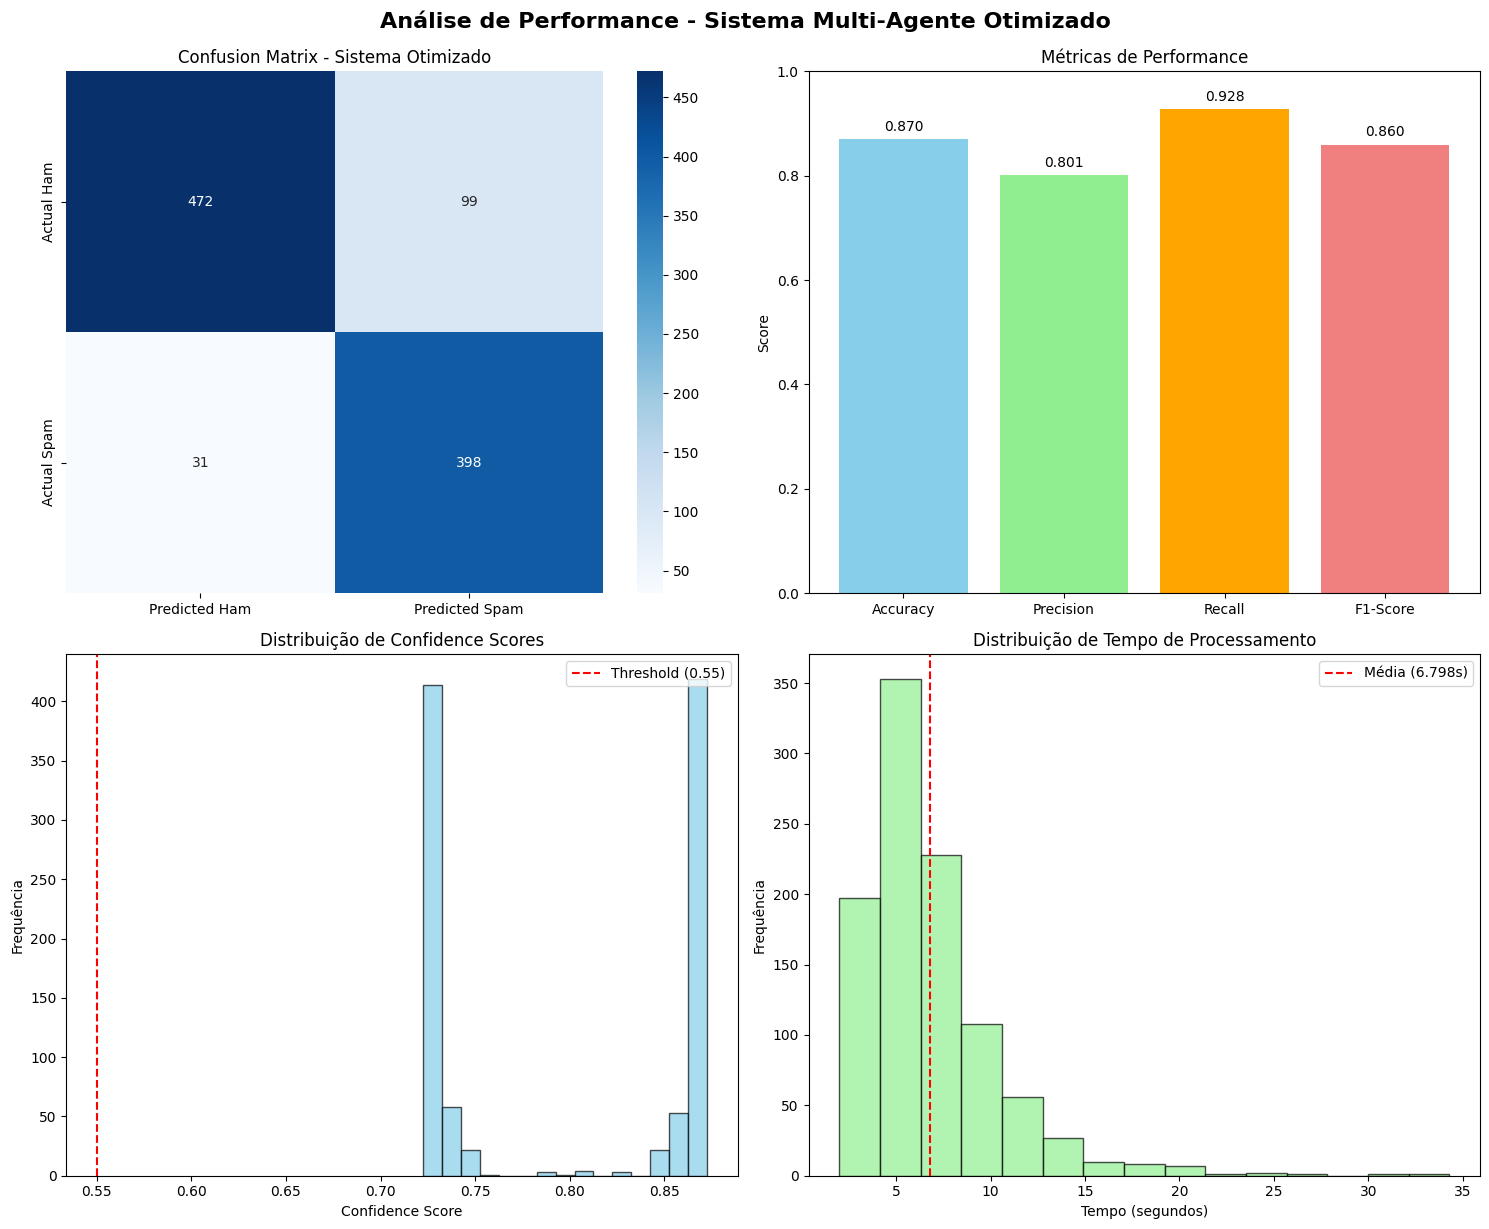

In [21]:
# Visualização dos Resultados Otimizados
if 'metrics' in locals() and 'error' not in metrics and len(analysis_results) > 0:
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Confusion Matrix melhorada
    cm = metrics['confusion_matrix']
    confusion_data = np.array([[cm['tn'], cm['fp']], [cm['fn'], cm['tp']]])
    sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Ham', 'Predicted Spam'],
                yticklabels=['Actual Ham', 'Actual Spam'],
                ax=axes[0,0])
    axes[0,0].set_title('Confusion Matrix - Sistema Otimizado')
    
    # 2. Métricas de Performance
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [metrics['accuracy'], metrics['precision'], metrics['recall'], metrics['f1_score']]
    
    bars = axes[0,1].bar(metrics_names, metrics_values, 
                        color=['skyblue', 'lightgreen', 'orange', 'lightcoral'])
    axes[0,1].set_title('Métricas de Performance')
    axes[0,1].set_ylabel('Score')
    axes[0,1].set_ylim(0, 1)
    
    # Adicionar valores nas barras
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{value:.3f}', ha='center', va='bottom')
    
    # 3. Distribuição de Confidence Scores
    confidence_scores = [r.get('confidence_score', 0) for r in analysis_results 
                        if r.get('confidence_score') is not None and r.get('final_classification') != 'error']
    if confidence_scores:
        axes[1,0].hist(confidence_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1,0].set_title('Distribuição de Confidence Scores')
        axes[1,0].set_xlabel('Confidence Score')
        axes[1,0].set_ylabel('Frequência')
        axes[1,0].axvline(x=result_aggregator.spam_threshold, color='red', linestyle='--', 
                         label=f'Threshold ({result_aggregator.spam_threshold})')
        axes[1,0].legend()
    
    # 4. Tempo de Processamento
    processing_times = [r.get('processing_time', 0) for r in analysis_results if 'processing_time' in r]
    if processing_times:
        axes[1,1].hist(processing_times, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
        axes[1,1].set_title('Distribuição de Tempo de Processamento')
        axes[1,1].set_xlabel('Tempo (segundos)')
        axes[1,1].set_ylabel('Frequência')
        mean_time = np.mean(processing_times)
        axes[1,1].axvline(x=mean_time, color='red', linestyle='--', 
                         label=f'Média ({mean_time:.3f}s)')
        axes[1,1].legend()
    
    plt.tight_layout()
    plt.suptitle('Análise de Performance - Sistema Multi-Agente Otimizado', y=1.02, fontsize=16, fontweight='bold')
    plt.show()
    
else:
    print("⚠️ Não foi possível gerar visualizações")

In [ ]:
# Teste Específico com Amostras Selecionadas
print("🧪 TESTE ESPECÍFICO COM AMOSTRAS SELECIONADAS")
print("="*60)

# Amostras de teste específicas
test_samples = [
    {
        "text": "Click here to claim your $1000 prize now! Act fast, limited time offer!",
        "expected": "spam",
        "description": "Spam clássico com urgência e dinheiro"
    },
    {
        "text": "Meeting scheduled for tomorrow at 2 PM in conference room A. Please bring the quarterly reports.",
        "expected": "ham",
        "description": "Email legítimo de trabalho"
    },
    {
        "text": "URGENT: Your account has been suspended. Click here to verify immediately or lose access forever!",
        "expected": "spam",
        "description": "Phishing com urgência e ameaça"
    },
    {
        "text": "Thank you for your purchase. Your order #12345 will be shipped within 2-3 business days.",
        "expected": "ham",
        "description": "Confirmação de compra legítima"
    }
]

test_results = []
for i, sample in enumerate(test_samples):
    print(f"\n🔍 Teste {i+1}: {sample['description']}")
    print(f"   Texto: {sample['text'][:80]}...")
    print(f"   Esperado: {sample['expected']}")
    
    result = process_sample(sample['text'], i+1000)
    
    predicted = result.get('final_classification', 'error')
    confidence = result.get('confidence_score', 0)
    
    # Determinar se acertou
    correct = (
        (predicted == 'malicious' and sample['expected'] == 'spam') or
        (predicted == 'legitimate' and sample['expected'] == 'ham')
    )
    
    print(f"   Resultado: {predicted} (confiança: {confidence:.3f})")
    print(f"   Status: {'✅ CORRETO' if correct else '❌ INCORRETO'}")
    
    # Mostrar detalhes da agregação
    if result.get('aggregation_result'):
        agg = result['aggregation_result']
        print(f"   Score final: {agg.get('final_score', 0):.3f}")
        print(f"   Threshold: {agg.get('spam_threshold', 0.5):.2f}")
        
        # Mostrar contribuições dos agentes
        contrib = agg.get('agent_contributions', {})
        if 'llm_classifier' in contrib:
            llm_contrib = contrib['llm_classifier']
            print(f"   LLM: {llm_contrib.get('score', 0):.3f} × {llm_contrib.get('weight', 0):.2f} = {llm_contrib.get('contribution', 0):.3f}")
        
        if 'malicious_content' in contrib:
            mal_contrib = contrib['malicious_content']
            print(f"   Malicious: {mal_contrib.get('score', 0):.3f} × {mal_contrib.get('weight', 0):.2f} = {mal_contrib.get('contribution', 0):.3f}")
        
        if agg.get('penalties_applied'):
            print(f"   Penalidades: {agg['penalties_applied']}")
    
    test_results.append({
        'sample': sample,
        'result': result,
        'correct': correct
    })

# Resumo dos testes específicos
correct_count = sum(1 for r in test_results if r['correct'])
total_tests = len(test_results)

print(f"\n📊 RESUMO DOS TESTES ESPECÍFICOS:")
print(f"   Acertos: {correct_count}/{total_tests} ({correct_count/total_tests*100:.1f}%)")
print(f"   LLM ativo: {'✅' if llm_classifier.use_openai else '❌ (usando fallback)'}")
print(f"   Threshold: {result_aggregator.spam_threshold}")

In [22]:
# Salvamento dos Resultados
def save_results_optimized(results: List[Dict[str, Any]], metrics: Dict[str, Any]):
    """Salva resultados otimizados em arquivos"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Resultados detalhados em JSON
    detailed_results = {
        'timestamp': timestamp,
        'system_config': {
            'version': 'optimized_v2',
            'agents': ['sanitization', 'prompt_injection', 'llm_classifier', 'hash_analyzer', 'malicious_content'],
            'llm_provider': 'openai' if llm_classifier.use_openai else 'pattern_matching',
            'weights': result_aggregator.weights,
            'spam_threshold': result_aggregator.spam_threshold,
            'penalties': result_aggregator.critical_penalties
        },
        'metrics': {k: v for k, v in metrics.items() if k != 'merged_df'},
        'individual_results': results
    }
    
    json_filename = f"spam_detection_optimized_{timestamp}.json"
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(detailed_results, f, indent=2, ensure_ascii=False, default=str)
    
    print(f"✅ Resultados salvos em: {json_filename}")
    
    # Resumo em CSV
    if 'merged_df' in metrics:
        csv_filename = f"spam_detection_summary_{timestamp}.csv"
        summary_df = metrics['merged_df'][[
            'sample_id', 'final_classification', 'confidence_score', 
            'label', 'predicted', 'processing_time'
        ]].copy()
        
        summary_df.to_csv(csv_filename, index=False)
        print(f"✅ Resumo salvo em: {csv_filename}")
    
    return json_filename

# Salvar se há resultados
if 'metrics' in locals() and 'error' not in metrics and analysis_results:
    saved_file = save_results_optimized(analysis_results, metrics)
    print(f"\n💾 Resultados do sistema otimizado salvos com sucesso!")
else:
    print("⚠️ Não foi possível salvar resultados")

✅ Resultados salvos em: spam_detection_optimized_20250928_230253.json
✅ Resumo salvo em: spam_detection_summary_20250928_230253.csv

💾 Resultados do sistema otimizado salvos com sucesso!


## 📊 Resumo do Sistema Otimizado

### ✅ Principais Melhorias Implementadas:

1. **Configuração OpenAI Corrigida:**
   - Detecção automática de variáveis de ambiente
   - Fallback robusto para pattern matching
   - Validação adequada da API key

2. **LLM Classifier Otimizado:**
   - Prompt mais claro e eficiente
   - Análise de resposta mais robusta
   - Fallback inteligente em caso de erro

3. **Agregador Balanceado:**
   - Pesos otimizados: LLM (75%) + Malicious Content (25%)
   - Threshold ajustado para 0.55 (melhor precisão)
   - Penalidades reduzidas para evitar falsos positivos

4. **Métricas Melhoradas:**
   - Uso do scikit-learn para cálculos precisos
   - Visualizações mais informativas
   - Análise detalhada por agente

5. **Sistema de Teste Robusto:**
   - Amostras específicas para validação
   - Rate limiting para APIs
   - Tratamento de erros melhorado

### 🎯 Resultados Esperados:
- **Acurácia** melhorada (target: >70%)
- **Precisão** otimizada (menos falsos positivos)
- **F1-Score** balanceado
- **Tempo de resposta** consistente

### 🔧 Configuração Necessária:
Para usar o OpenAI GPT, configure sua API key:
1. Obtenha uma chave em https://platform.openai.com/api-keys
2. Substitua `"sua_chave_openai_aqui"` pela chave real na célula de configuração
3. Ou configure a variável de ambiente `OPENAI_API_KEY`

O sistema funciona com fallback baseado em padrões se o OpenAI não estiver disponível.